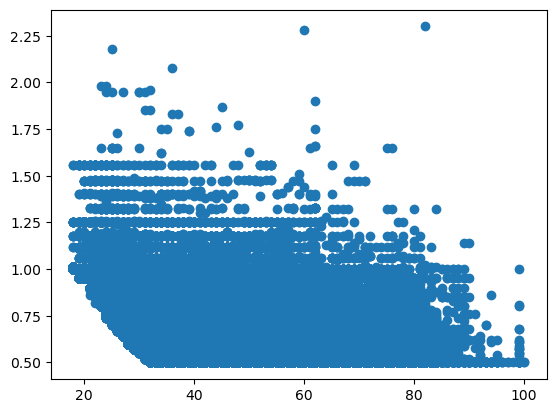

(405763, 12)


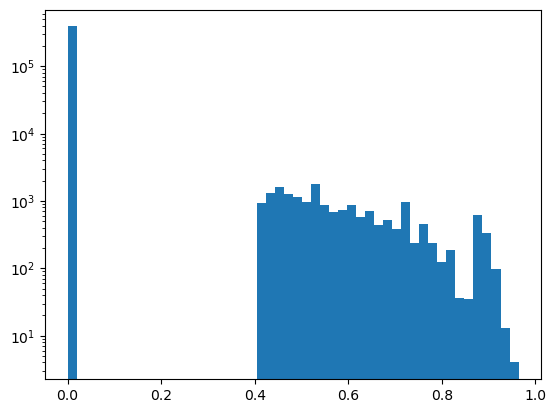

In [ ]:
import pandas as pd
import numpy as np
from filter_data import filtering

df1 = pd.read_csv('/Users/swenpai/machine-n-learnings-inc/src/claims_train.csv')
df1 = filtering(df1)

Decision Tree

In [ ]:
class DecisionTreeScratch:

    def __init__(self, max_depth=5, min_samples_split=10, min_samples_leaf=1, max_leaf_nodes=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_leaf_nodes = max_leaf_nodes
        self.tree = None
        self.n_leaves = 0

    def fit(self, X, y):
        self.n_leaves = 0
        self.tree = self.build_tree(X, y, depth=0)

    def build_tree(self, X, y, depth):
        if depth >= self.max_depth or len(y) < self.min_samples_split:
            self.n_leaves += 1
            return {"value": np.mean(y)}

        best_feature, best_thresh, best_score = None, None, float("inf")
        best_left, best_right = None, None

        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = X[:, feature] > threshold

                if left_mask.sum() < self.min_samples_leaf or right_mask.sum() < self.min_samples_leaf:
                    continue

                y_left, y_right = y[left_mask], y[right_mask]
                mse = (len(y_left)*np.var(y_left) + len(y_right)*np.var(y_right)) / len(y)

                if mse < best_score:
                    best_feature, best_thresh = feature, threshold
                    best_score = mse
                    best_left, best_right = (X[left_mask], y_left), (X[right_mask], y_right)

        if best_feature is None:
            self.n_leaves += 1
            return {"value": np.mean(y)}

        if self.max_leaf_nodes is not None and self.n_leaves >= self.max_leaf_nodes:
            self.n_leaves += 1
            return {"value": np.mean(y)}

        left_branch = self.build_tree(best_left[0], best_left[1], depth + 1)
        right_branch = self.build_tree(best_right[0], best_right[1], depth + 1)

        return {"feature": best_feature,
                "threshold": best_thresh,
                "left": left_branch,
                "right": right_branch}

    def single_pred(self, x, node):
        if "value" in node:
            return node["value"]

        if x[node["feature"]] <= node["threshold"]:
            return self.single_pred(x, node["left"])
        else:
            return self.single_pred(x, node["right"])

    def predict(self, X):
        return np.array([self.single_pred(x, self.tree) for x in X])


    def prune(self, X_val, y_val):
        self.prune_node(self.tree, X_val, y_val)

    def prune_node(self, node, X, y):
        if "value" in node:
            return

        feature = node["feature"]
        threshold = node["threshold"]

        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold

        self.prune_node(node["left"], X[left_mask], y[left_mask])
        self.prune_node(node["right"], X[right_mask], y[right_mask])

        y_pred_keep = np.array([self.single_pred(x, node) for x in X])
        keep_error = np.mean((y - y_pred_keep)**2)

        leaf_value = np.mean(y)
        prune_error = np.mean((y - leaf_value)**2)

        if prune_error <= keep_error:
            node.clear()
            node["value"] = leaf_value

    def print_tree(self, node=None, depth=0):
        if node is None:
            node = self.tree

        indent = "  " * depth

        # Leaf node
        if "value" in node:
            print(f"{indent}Leaf: value={node['value']:.4f}")
            return

        # Internal node
        print(f"{indent}Feature[{node['feature']}] <= {node['threshold']}")

        # Left subtree
        print(f"{indent}├── Left:")
        self.print_tree(node["left"], depth + 1)

        # Right subtree
        print(f"{indent}└── Right:")
        self.print_tree(node["right"], depth + 1)



Cross-Validation

In [ ]:
def kfold_split(n_samples, k=5, seed=42):
    np.random.seed(seed)
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    return np.array_split(indices, k)


def cross_validate_tree(df, target_col, tree_class, features, k=5, seed=42, **tree_kwargs):
    folds = kfold_split(len(df), k=k, seed=seed)
    mse_scores = []
    best_tree = None
    best_mse = float("inf")

    for i in range(k):
        val_idx = folds[i]
        train_idx = np.setdiff1d(np.arange(len(df)), val_idx)

        # selcts features and target column
        X_train = df.iloc[train_idx][features].to_numpy()
        y_train = df.iloc[train_idx][target_col].to_numpy()
        X_val = df.iloc[val_idx][features].to_numpy()
        y_val = df.iloc[val_idx][target_col].to_numpy()

        # trains tree using the hyperparameters
        tree = tree_class(**tree_kwargs)
        tree.fit(X_train, y_train)

        # pruining
        tree.prune(X_val, y_val)

        # Evaluate validation MSE
        y_val_pred = tree.predict(X_val)
        mse = np.mean((y_val - y_val_pred)**2)
        mse_scores.append(mse)

        # Keep the best tree
        if mse < best_mse:
            best_mse = mse
            best_tree = tree

        print(f"Fold {i+1}/{k} - Validation MSE: {mse:.4f}")

    print(f"Best validation MSE: {best_mse:.4f}")
    return mse_scores, best_tree


def predict_tree(tree, df, features):
    X = df[features].to_numpy()
    return tree.predict(X)

Evaluation

In [ ]:
features = ["VehPower", "VehAge", "DrivAge", "BonusMalus", "Density"]

# Perform 5-fold CV and get the best tree
mse_scores, best_tree = cross_validate_tree(
    df=df1,
    target_col="Risk",
    tree_class=DecisionTreeScratch,
    features=features,
    k=5,
    max_depth=5,
    min_samples_split=20
)

# Predict a single row
single_row = df1.iloc[0:1]  # keep as DataFrame
pred_single = predict_tree(best_tree, single_row, features)
print(f"Predicted risk for single row: {pred_single[0]:.5f}")
# First 10 actual target values
actual_values = df1["risk"].iloc[:10]
print("Actual risk values for first 10 rows:")
print(actual_values.values)


# Predict multiple rows
pred_batch = predict_tree(best_tree, df1.iloc[:10], features)
print("Predictions for first 10 rows:", pred_batch)

KeyError: 'risk'

In [ ]:
best_tree.print_tree()

Feature[1] <= 0.0
├── Left:
  Feature[0] <= 6.0
  ├── Left:
    Feature[0] <= 4.0
    ├── Left:
      Feature[2] <= 56.0
      ├── Left:
        Leaf: value=0.0513
      └── Right:
        Leaf: value=0.0397
    └── Right:
      Feature[0] <= 5.0
      ├── Left:
        Leaf: value=0.0762
      └── Right:
        Leaf: value=0.0540
  └── Right:
    Feature[0] <= 8.0
    ├── Left:
      Feature[0] <= 7.0
      ├── Left:
        Leaf: value=0.0444
      └── Right:
        Leaf: value=0.0119
    └── Right:
      Feature[0] <= 10.0
      ├── Left:
        Feature[0] <= 9.0
        ├── Left:
          Leaf: value=0.0992
        └── Right:
          Leaf: value=0.0721
      └── Right:
        Leaf: value=0.0174
└── Right:
  Feature[3] <= 0.9985023194168323
  ├── Left:
    Feature[3] <= 0.57
    ├── Left:
      Feature[2] <= 41.0
      ├── Left:
        Leaf: value=0.0142
      └── Right:
        Feature[1] <= 4.0
        ├── Left:
          Leaf: value=0.0162
        └── Right:
          Lea